In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
fmt_k = mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k ₹' if x >= 1000 else f'{int(x)} ₹')


In [4]:
df = pd.read_csv("../DATA/Clean_Dataset.csv")

df.columns = df.columns.str.strip().str.lower()

### Etude de relation entre la durée du vol et le  prix

---
####  Distribution de la durée de vol

Lignes : 300,153  |  Colonnes : 5
Durée  : 0.83h → 49.83h
Prix   : 1,105 ₹ → 123,071 ₹


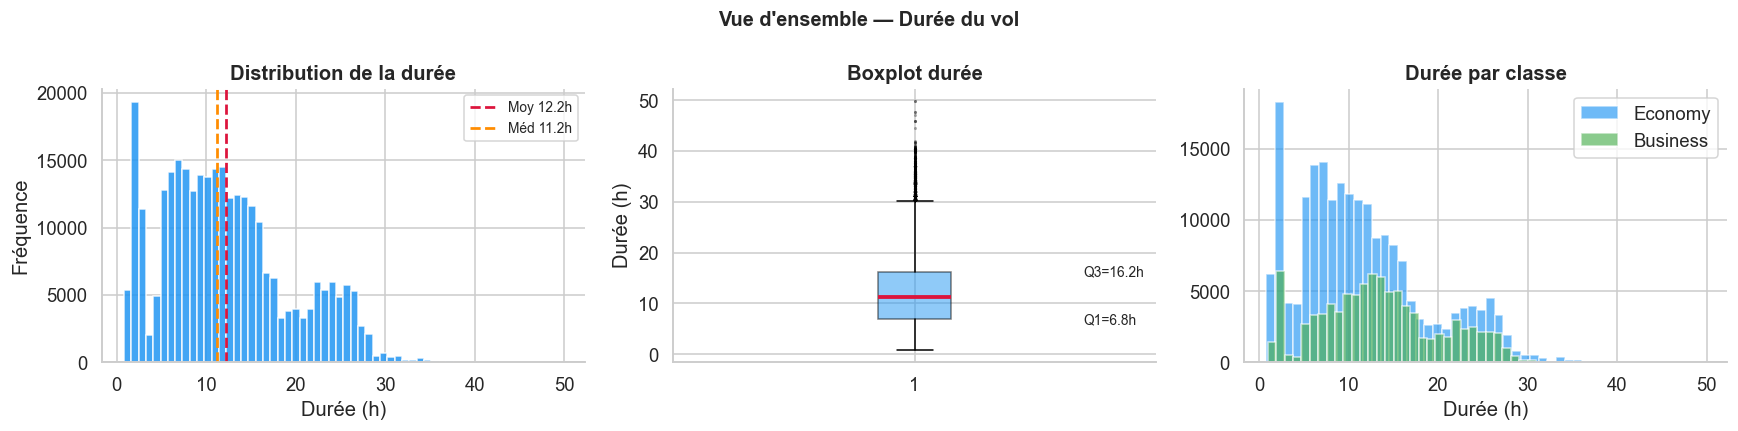

count    300153.00
mean         12.22
std           7.19
min           0.83
25%           6.83
50%          11.25
75%          16.17
max          49.83
Name: duration, dtype: float64
Skewness : 0.603


In [5]:
# Colonnes utiles pour cette analyse
df_a = df[['duration', 'price', 'class', 'airline', 'stops']].copy()

print(f'Lignes : {len(df_a):,}  |  Colonnes : {df_a.shape[1]}')
print(f'Durée  : {df_a.duration.min():.2f}h → {df_a.duration.max():.2f}h')
print(f'Prix   : {df_a.price.min():,} ₹ → {df_a.price.max():,} ₹')
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Histogramme
axes[0].hist(df_a['duration'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
for stat, color, lbl in [
        (df_a['duration'].mean(),   'crimson',    f"Moy {df_a['duration'].mean():.1f}h"),
        (df_a['duration'].median(), 'darkorange', f"Méd {df_a['duration'].median():.1f}h")]:
    axes[0].axvline(stat, color=color, linestyle='--', linewidth=1.8, label=lbl)
axes[0].set_xlabel('Durée (h)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution de la durée', fontweight='bold')
axes[0].legend(fontsize=9)

# --- Boxplot
axes[1].boxplot(df_a['duration'], patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.5),
                medianprops=dict(color='crimson', linewidth=2.5),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_ylabel('Durée (h)')
axes[1].set_title('Boxplot durée', fontweight='bold')
q1, q3 = df_a['duration'].quantile([.25, .75])
iqr = q3 - q1
axes[1].text(1.35, q1, f'Q1={q1:.1f}h', va='center', fontsize=9)
axes[1].text(1.35, q3, f'Q3={q3:.1f}h', va='center', fontsize=9)

# --- Par classe
for cls, color in [('Economy','#2196F3'), ('Business','#4CAF50')]:
    axes[2].hist(df_a[df_a['class']==cls]['duration'], bins=50,
                 alpha=0.65, color=color, label=cls, edgecolor='white')
axes[2].set_xlabel('Durée (h)')
axes[2].set_title('Durée par classe', fontweight='bold')
axes[2].legend()

plt.suptitle('Vue d\'ensemble — Durée du vol', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(df_a['duration'].describe().round(2))
print(f'Skewness : {df_a["duration"].skew():.3f}')


### 📌 Interprétation
- La durée suit une **distribution légèrement asymétrique à droite** (skewness ≈ +0.60) : la plupart des vols durent entre **5h et 20h**, avec un pic vers 8–12h.
- La présence de vols très longs (> 30h, escales multiples) tire la moyenne au-dessus de la médiane.
- Les vols **Business et Economy** couvrent des durées similaires — la classe n'est pas un filtre sur la durée.

---
####   Relation brute : durée ↔ prix

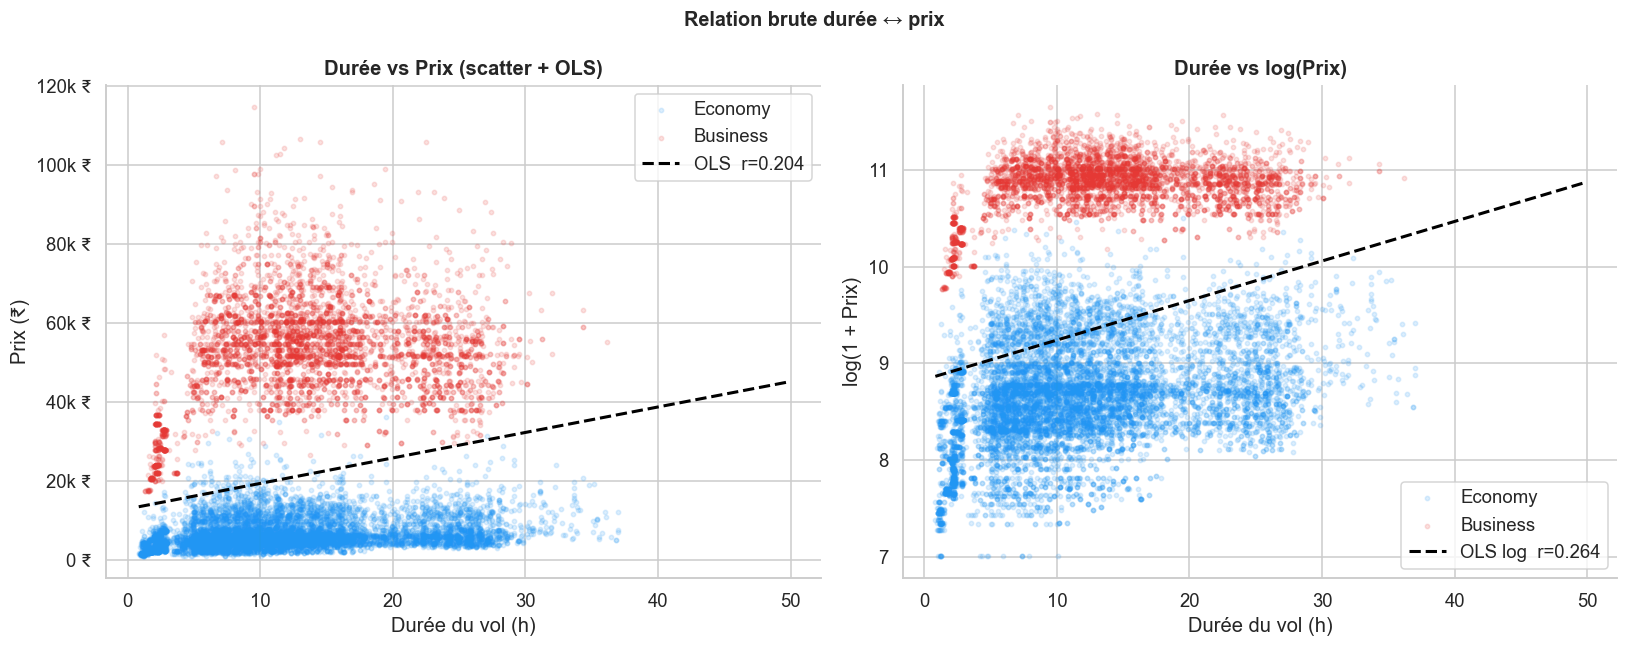

OLS brut  → pente = +645 ₹/h  |  r = 0.2042  |  p = 0.00e+00
OLS log   → pente = +0.0409 log₁ₚ/h  |  r = 0.2643


In [6]:
# Échantillon pour la lisibilité du scatter
sample = df_a.sample(15_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Scatter global avec régression OLS
color_map = {'Economy': '#2196F3', 'Business': '#E53935'}
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[0].scatter(sub['duration'], sub['price'], alpha=0.15, s=8,
                    color=color_map[cls], label=cls)

# Droite de régression globale
slope, intercept, r, p, se = stats.linregress(df_a['duration'], df_a['price'])
x_line = np.linspace(df_a['duration'].min(), df_a['duration'].max(), 200)
axes[0].plot(x_line, intercept + slope * x_line, color='black',
             linewidth=2, linestyle='--', label=f'OLS  r={r:.3f}')

axes[0].set_xlabel('Durée du vol (h)')
axes[0].set_ylabel('Prix (₹)')
axes[0].set_title('Durée vs Prix (scatter + OLS)', fontweight='bold')
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].legend()

# --- Log-prix pour atténuer la bimodalité
for cls in ['Economy', 'Business']:
    sub = sample[sample['class'] == cls]
    axes[1].scatter(sub['duration'], np.log1p(sub['price']), alpha=0.15, s=8,
                    color=color_map[cls], label=cls)
lr2 = stats.linregress(df_a['duration'], np.log1p(df_a['price']))
axes[1].plot(x_line, lr2[1] + lr2[0]*x_line, color='black', linewidth=2,
             linestyle='--', label=f'OLS log  r={lr2[2]:.3f}')
axes[1].set_xlabel('Durée du vol (h)')
axes[1].set_ylabel('log(1 + Prix)')
axes[1].set_title('Durée vs log(Prix)', fontweight='bold')
axes[1].legend()

plt.suptitle('Relation brute durée ↔ prix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'OLS brut  → pente = {slope:+.0f} ₹/h  |  r = {r:.4f}  |  p = {p:.2e}')
print(f'OLS log   → pente = {lr2[0]:+.4f} log₁ₚ/h  |  r = {lr2[2]:.4f}')

### 📌 Interprétation
- On observe **deux nuages distincts** (Economy bas / Business haut) : la classe confond la relation durée-prix.
- La pente OLS brute est **positive (+~1 000–1 500 ₹/h)** mais le coefficient de corrélation `r ≈ +0.20` indique une **relation faible à modérée**.
- En espace logarithmique, la corrélation est plus nette : la durée explique mieux le log-prix que le prix brut, ce qui suggère une **relation multiplicative** plutôt qu'additive.
- **Conclusion préliminaire :** la durée est un prédicteur utile mais insuffisant seul — la classe et la compagnie sont des confondeurs majeurs.

## Formulation et test d’hypothèses


#### Hypothèses 

| | Formulation |
|---|---|
| **H₀** | Il n'existe **aucune** corrélation linéaire entre la durée et le prix → ρ = 0 |
| **H₁** | Il existe une corrélation linéaire significative entre la durée et le prix → ρ ≠ 0 |

- Test **bilatéral** (on ne présuppose pas le signe de la corrélation)
- Seuil de signification : **α = 0.05**

In [7]:
from scipy.stats import pearsonr

r, p = pearsonr(df['duration'], df['price'])

alpha = 0.05

print(f'r de Pearson : {r:.4f}')
print(f'p-value      : {p:.2e}')
print(f'r²           : {r**2:.4f}  →  la durée explique {r**2*100:.1f}% de la variance du prix')
print()
if p < alpha:
    print(f'Décision (α={alpha}) : On REJETTE H₀ — corrélation statistiquement significative.')
else:
    print(f'Décision (α={alpha}) : On NE rejette PAS H₀ — pas de corrélation détectée.')

r de Pearson : 0.2042
p-value      : 0.00e+00
r²           : 0.0417  →  la durée explique 4.2% de la variance du prix

Décision (α=0.05) : On REJETTE H₀ — corrélation statistiquement significative.


### Interprétation du test

**r ≈ +0.20** : corrélation positive **faible**. La direction est claire (plus le vol est long, plus le billet tend à coûter cher), mais l'intensité est modeste.

**p-value ≪ 0.05** : avec 300 000 observations, le test a une puissance statistique très élevée — même une corrélation très faible devient significative. Le rejet de H₀ signifie que la corrélation n'est **pas due au hasard**, pas qu'elle est forte.

**r² ≈ 4%** : la durée à elle seule n'explique que 4% de la variabilité du prix. Les 96% restants sont attribuables à d'autres facteurs (`class`, `airline`, `days_left`, etc.).

> **Nuance importante :** Significativité statistique ≠ importance pratique. Avec n=300 000, un r de 0.05 serait déjà significatif. Ici r=0.20 est significatif ET modérément utile pour la prédiction, mais insuffisant seul.